# 05 Feature Engineering (Week 6)

This notebook extends the Week 4 baseline by creating new features, adding unified school district information, and comparing several feature-engineering strategies on the same holdout month.

## Week 6 Goal

The goal for Week 6 is to improve the model through thoughtful feature engineering rather than by changing the evaluation setup.

This notebook keeps the same latest full month as the test set and keeps the same six-month training window that performed better than the three-month window.

It compares five feature sets:

- `baseline_features`: the retained Week 4 linear-regression feature set
- `compact_engineered_features`: baseline plus a small set of numeric engineered features
- `refined_engineered_features`: baseline plus smoother numeric transforms and a simple district indicator
- `district_swap_features`: baseline structure with school district replacing county
- `full_engineered_features`: the most expanded version with all new features together

The main question is which feature-engineering strategy improves `R2`, `MAPE`, and `MdAPE` on the same holdout month without making the model noisier.

In [21]:
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from shapely.geometry import Point
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

project_root = Path("../").resolve()
output_dir = project_root / "outputs"
raw_dir = project_root / "data" / "raw"
data_path = output_dir / "full_preprocessed_week3.csv"

print(f"Project root: {project_root}")
print(f"Base dataset: {data_path}")

Project root: /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026
Base dataset: /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/full_preprocessed_week3.csv


## Load The Base Dataset

The starting point is the cleaned Week 3 dataset that was already used for Week 4 and Week 5. This keeps the project consistent and avoids rebuilding preprocessing from raw files again.

In [22]:
df = pd.read_csv(data_path)
df["CloseDate"] = pd.to_datetime(df["CloseDate"])
df["close_month"] = pd.to_datetime(df["close_month"])

available_months = sorted(df["close_month"].dropna().unique())
test_month = available_months[-1]
train_months = available_months[-7:-1]

train_df = df[df["close_month"].isin(train_months)].copy()
test_df = df[df["close_month"] == test_month].copy()

print(f"Full dataset rows: {len(df):,}")
print(f"Training months: {[str(pd.Timestamp(m).date()) for m in train_months]}")
print(f"Test month: {pd.Timestamp(test_month).date()}")
print(f"Training rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")

display(df.head())

Full dataset rows: 71,352
Training months: ['2025-11-01', '2025-12-01', '2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01']
Test month: 2026-05-01
Training rows: 59,345
Test rows: 12,007


,ClosePrice,CloseDate,close_month,ListPrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,Latitude,Longitude,DaysOnMarket,property_age,log_living_area,bathrooms_per_bedroom,CountyOrParish
0,1250000.0,2025-11-30,2025-11-01,1250000.0,1027.0,3.0,2.0,5913.0,1961.0,33.676050,-117.995210,0.0,64.0,6.935370,0.666667,Orange
1,2299995.0,2025-11-20,2025-11-01,2299995.0,1129.0,3.0,1.0,18432.0,1949.0,37.260693,-121.934121,0.0,76.0,7.029973,0.333333,Santa Clara
2,810000.0,2025-11-26,2025-11-01,799900.0,1619.0,4.0,3.0,5300.0,1978.0,32.564997,-117.064393,0.0,47.0,7.390181,0.750000,San Diego
3,925000.0,2025-11-17,2025-11-01,925000.0,2872.0,5.0,3.0,5272.0,2000.0,32.575778,-117.024433,0.0,25.0,7.963112,0.600000,San Diego
4,1300000.0,2025-11-25,2025-11-01,1300000.0,1727.0,3.0,2.0,10500.0,1950.0,35.553064,-120.708510,0.0,75.0,7.454720,0.666667,San Luis Obispo


## Create New Features

These features are kept simple and explainable:

- `list_price_per_sqft`: listing price intensity
- `lot_to_living_ratio`: relative lot size
- `is_newer_home`: built in 2000 or later
- `high_bedroom_flag`: at least four bedrooms
- `bedrooms_per_1000_sqft`: bedroom density relative to size
- `log_lot_size`: log-transformed lot size
- `log_days_on_market`: log-transformed days on market
- `living_area_per_bedroom`: average interior space per bedroom
- `is_unknown_district`: whether the school district could not be matched

A smaller feature set and a refined feature set will both be tested because the first Week 6 run suggested that adding too many variables at once may hurt linear regression.

,ListPrice,LivingArea,LotSizeSquareFeet,BedroomsTotal,YearBuilt,list_price_per_sqft,lot_to_living_ratio,is_newer_home,high_bedroom_flag,bedrooms_per_1000_sqft,log_lot_size,log_days_on_market,living_area_per_bedroom
0,1250000.0,1027.0,5913.0,3.0,1961.0,1217.137293,5.757546,0,0,2.921130,8.685078,0.0,342.333333
1,2299995.0,1129.0,18432.0,3.0,1949.0,2037.196634,16.325952,0,0,2.657219,9.821898,0.0,376.333333
2,799900.0,1619.0,5300.0,4.0,1978.0,494.070414,3.273626,0,1,2.470661,8.575651,0.0,404.750000
3,925000.0,2872.0,5272.0,5.0,2000.0,322.075209,1.835655,1,1,1.740947,8.570355,0.0,574.400000
4,1300000.0,1727.0,10500.0,3.0,1950.0,752.750434,6.079907,0,0,1.737116,9.259226,0.0,575.666667


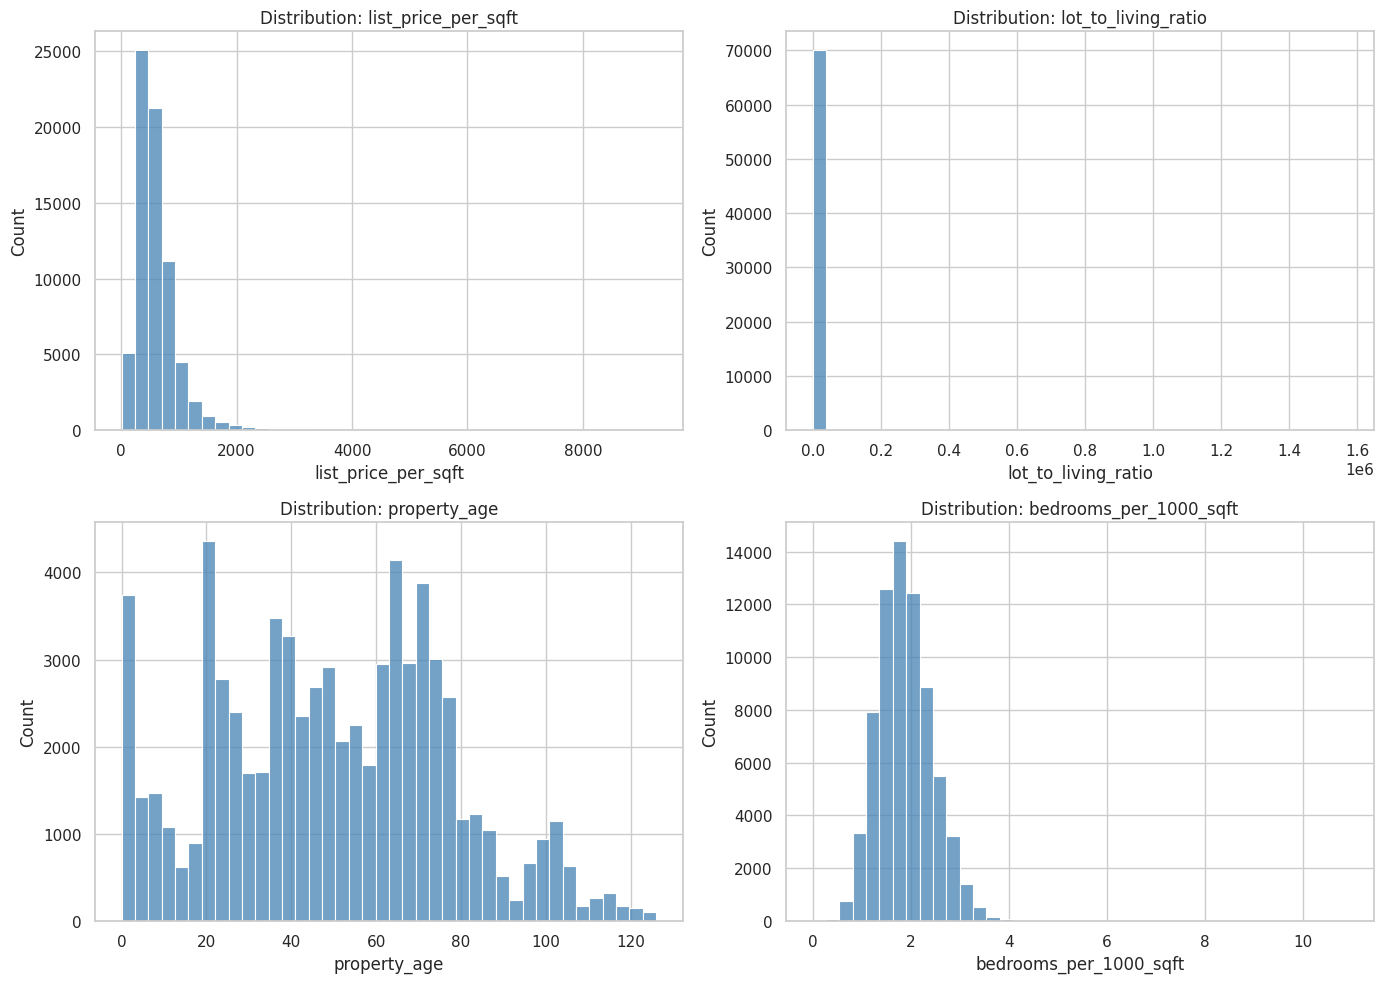

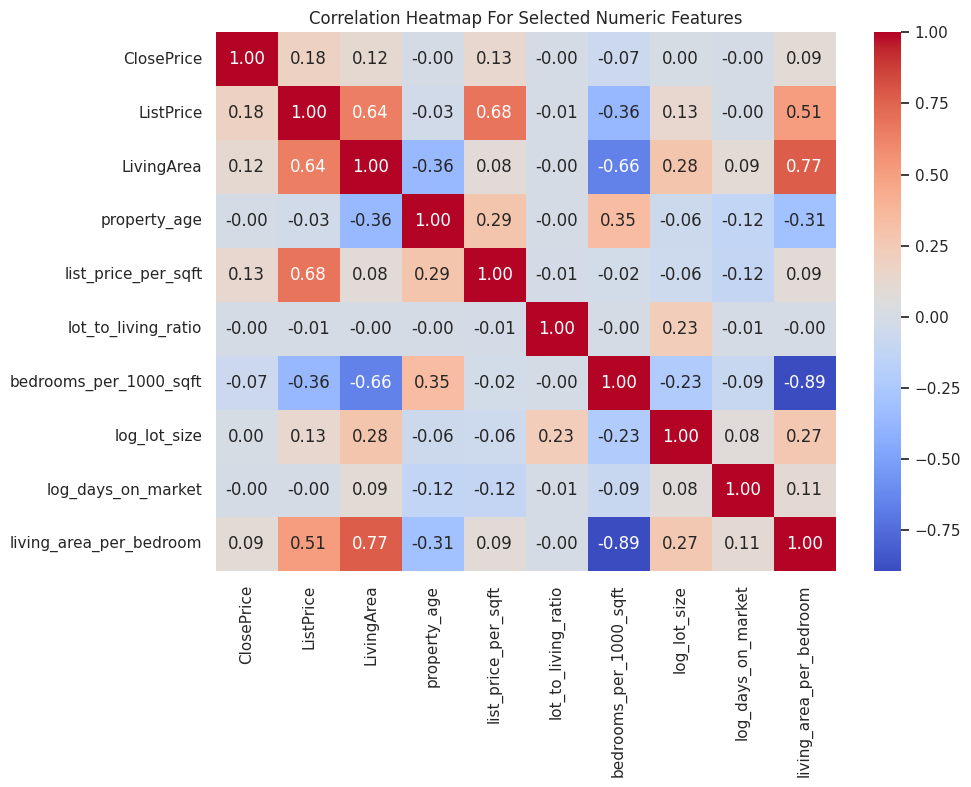

In [23]:
engineered_df = df.copy()

living_area_safe = engineered_df["LivingArea"].replace(0, np.nan)

engineered_df["list_price_per_sqft"] = engineered_df["ListPrice"] / living_area_safe
engineered_df["lot_to_living_ratio"] = (
    engineered_df["LotSizeSquareFeet"] / living_area_safe
)
engineered_df["is_newer_home"] = (engineered_df["YearBuilt"] >= 2000).astype(int)
engineered_df["high_bedroom_flag"] = (engineered_df["BedroomsTotal"] >= 4).astype(int)
engineered_df["bedrooms_per_1000_sqft"] = engineered_df["BedroomsTotal"] / (
    living_area_safe / 1000
)
engineered_df["log_lot_size"] = np.log1p(
    engineered_df["LotSizeSquareFeet"].clip(lower=0)
)
engineered_df["log_days_on_market"] = np.log1p(
    engineered_df["DaysOnMarket"].clip(lower=0)
)
engineered_df["living_area_per_bedroom"] = living_area_safe / engineered_df[
    "BedroomsTotal"
].replace(0, np.nan)

feature_preview_cols = [
    "ListPrice",
    "LivingArea",
    "LotSizeSquareFeet",
    "BedroomsTotal",
    "YearBuilt",
    "list_price_per_sqft",
    "lot_to_living_ratio",
    "is_newer_home",
    "high_bedroom_flag",
    "bedrooms_per_1000_sqft",
    "log_lot_size",
    "log_days_on_market",
    "living_area_per_bedroom",
]

display(engineered_df[feature_preview_cols].head())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_columns = [
    "list_price_per_sqft",
    "lot_to_living_ratio",
    "property_age",
    "bedrooms_per_1000_sqft",
]

for ax, column in zip(axes.flatten(), plot_columns):
    clean_series = engineered_df[column].replace([np.inf, -np.inf], np.nan).dropna()
    sns.histplot(clean_series, bins=40, ax=ax, color="steelblue")
    ax.set_title(f"Distribution: {column}")

plt.tight_layout()
plt.show()

corr_columns = [
    "ClosePrice",
    "ListPrice",
    "LivingArea",
    "property_age",
    "list_price_per_sqft",
    "lot_to_living_ratio",
    "bedrooms_per_1000_sqft",
    "log_lot_size",
    "log_days_on_market",
    "living_area_per_bedroom",
]

plt.figure(figsize=(10, 7))
sns.heatmap(engineered_df[corr_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap For Selected Numeric Features")
plt.show()

## Add Unified School District

Group guidance said to map each property into a California unified school district using a spatial join.

This cell looks for a GeoJSON file in either `../data/raw/` or `../outputs/` and filters to `DistrictType == "Unified"` before the join.

Using school district file: /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/data/raw/california_school_districts_2025_26.geojson
Known district share: 75.80%


,CountyOrParish,unified_district_name
0,Orange,Unknown_District
1,Santa Clara,Unknown_District
2,San Diego,Unknown_District
3,San Diego,Unknown_District
4,San Luis Obispo,Templeton Unified


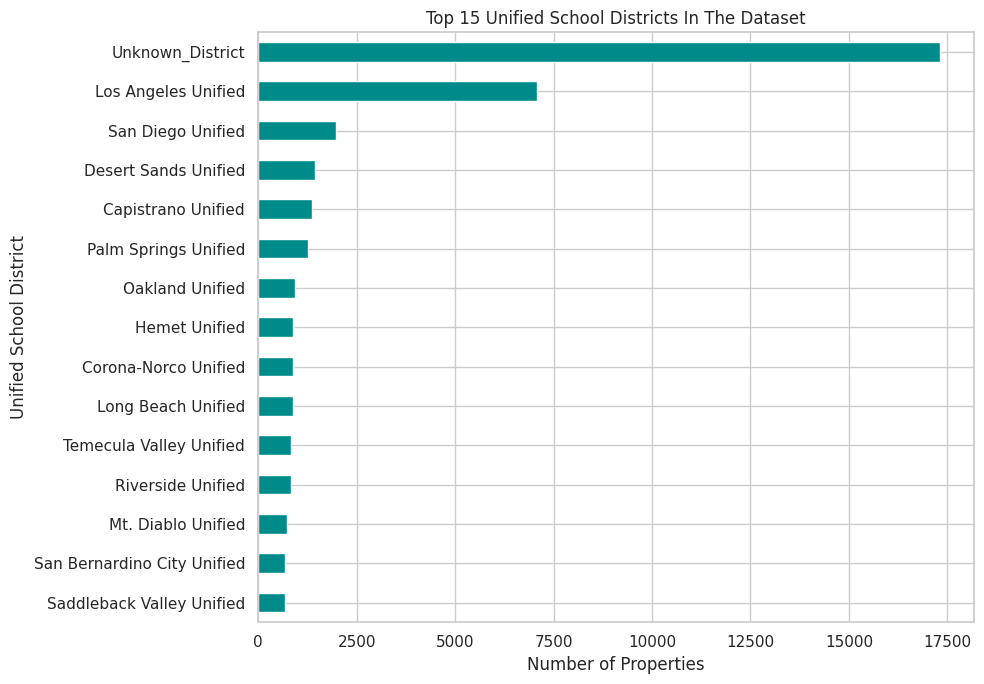

In [24]:
geojson_candidates = list(raw_dir.glob("*.geojson")) + list(
    output_dir.glob("*.geojson")
)

school_path = None
for candidate in geojson_candidates:
    name = candidate.name.lower()
    if "school" in name or "district" in name:
        school_path = candidate
        break

if school_path is None:
    raise FileNotFoundError(
        "School district GeoJSON not found. Download the California School District boundary GeoJSON and place it in ../data/raw/ or ../outputs/."
    )

print(f"Using school district file: {school_path}")

district_gdf = gpd.read_file(school_path)
district_gdf.columns = [str(col) for col in district_gdf.columns]

district_type_col = next(
    (col for col in district_gdf.columns if col.lower() == "districttype"), None
)
district_name_col = next(
    (col for col in district_gdf.columns if col.lower() == "districtname"), None
)

if district_type_col is None or district_name_col is None:
    raise KeyError(
        "Expected columns DistrictType and DistrictName were not found in the school district file."
    )

district_gdf = district_gdf[district_gdf[district_type_col] == "Unified"].copy()
district_gdf = district_gdf[[district_name_col, district_type_col, "geometry"]].rename(
    columns={
        district_name_col: "unified_district_name",
        district_type_col: "district_type",
    }
)

property_points = engineered_df.dropna(subset=["Latitude", "Longitude"]).copy()
property_points["geometry"] = [
    Point(xy) for xy in zip(property_points["Longitude"], property_points["Latitude"])
]
property_gdf = gpd.GeoDataFrame(property_points, geometry="geometry", crs="EPSG:4326")

if district_gdf.crs is None:
    district_gdf = district_gdf.set_crs("EPSG:4326")
elif district_gdf.crs != property_gdf.crs:
    district_gdf = district_gdf.to_crs(property_gdf.crs)

joined = gpd.sjoin(
    property_gdf,
    district_gdf[["unified_district_name", "district_type", "geometry"]],
    how="left",
    predicate="within",
)

joined = joined.drop(columns=[col for col in ["index_right"] if col in joined.columns])
joined["unified_district_name"] = joined["unified_district_name"].fillna(
    "Unknown_District"
)

engineered_df = engineered_df.merge(
    joined[["CloseDate", "Latitude", "Longitude", "unified_district_name"]],
    on=["CloseDate", "Latitude", "Longitude"],
    how="left",
)
engineered_df["unified_district_name"] = engineered_df["unified_district_name"].fillna(
    "Unknown_District"
)
engineered_df["is_unknown_district"] = (
    engineered_df["unified_district_name"] == "Unknown_District"
).astype(int)

district_coverage = (
    engineered_df["unified_district_name"] != "Unknown_District"
).mean()
print(f"Known district share: {district_coverage:.2%}")

display(engineered_df[["CountyOrParish", "unified_district_name"]].head())

top_districts = (
    engineered_df["unified_district_name"].value_counts().head(15).sort_values()
)
plt.figure(figsize=(10, 7))
top_districts.plot(kind="barh", color="darkcyan")
plt.title("Top 15 Unified School Districts In The Dataset")
plt.xlabel("Number of Properties")
plt.ylabel("Unified School District")
plt.tight_layout()
plt.show()

## Compare Feature Sets

To isolate the effect of feature engineering, the model family stays the same: linear regression.

This section compares four feature sets so it is easier to see whether a compact numeric expansion helps, whether school district helps when it replaces county, or whether the fully expanded version adds too much noise.

In [25]:
baseline_feature_cols = [
    "ListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "DaysOnMarket",
    "property_age",
    "log_living_area",
    "bathrooms_per_bedroom",
    "CountyOrParish",
]

compact_engineered_feature_cols = baseline_feature_cols + [
    "list_price_per_sqft",
    "lot_to_living_ratio",
    "is_newer_home",
]

refined_engineered_feature_cols = baseline_feature_cols + [
    "log_lot_size",
    "log_days_on_market",
    "living_area_per_bedroom",
    "is_unknown_district",
]

district_swap_feature_cols = [
    "ListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "DaysOnMarket",
    "property_age",
    "log_living_area",
    "bathrooms_per_bedroom",
    "unified_district_name",
]

full_engineered_feature_cols = baseline_feature_cols + [
    "list_price_per_sqft",
    "lot_to_living_ratio",
    "is_newer_home",
    "high_bedroom_flag",
    "bedrooms_per_1000_sqft",
    "unified_district_name",
]

feature_sets = {
    "baseline_features": baseline_feature_cols,
    "compact_engineered_features": compact_engineered_feature_cols,
    "refined_engineered_features": refined_engineered_feature_cols,
    "district_swap_features": district_swap_feature_cols,
    "full_engineered_features": full_engineered_feature_cols,
}

engineered_train_df = engineered_df[
    engineered_df["close_month"].isin(train_months)
].copy()
engineered_test_df = engineered_df[engineered_df["close_month"] == test_month].copy()


def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


def median_absolute_percentage_error(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.median(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


def build_pipeline(feature_columns, frame):
    numeric_features = [
        col for col in feature_columns if pd.api.types.is_numeric_dtype(frame[col])
    ]
    categorical_features = [
        col for col in feature_columns if col not in numeric_features
    ]

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LinearRegression()),
        ]
    )


results = []
prediction_frames = []

for label, feature_columns in feature_sets.items():
    X_train = engineered_train_df[feature_columns]
    y_train = engineered_train_df["ClosePrice"]
    X_test = engineered_test_df[feature_columns]
    y_test = engineered_test_df["ClosePrice"]

    pipeline = build_pipeline(feature_columns, engineered_train_df)
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    results.append(
        {
            "model_name": label,
            "train_rows": len(X_train),
            "test_rows": len(X_test),
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "R2": r2_score(y_test, preds),
            "MAPE": mean_absolute_percentage_error(y_test, preds),
            "MdAPE": median_absolute_percentage_error(y_test, preds),
        }
    )

    prediction_frames.append(
        pd.DataFrame(
            {
                "model_name": label,
                "actual": y_test.values,
                "predicted": preds,
                "residual": y_test.values - preds,
                "close_month": engineered_test_df["close_month"].astype(str).values,
            }
        )
    )

results_df = (
    pd.DataFrame(results)
    .sort_values(by=["R2", "MdAPE"], ascending=[False, True])
    .reset_index(drop=True)
)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

for metric_col in ["MAE", "RMSE"]:
    results_df[metric_col] = results_df[metric_col].round(2)
for metric_col in ["R2", "MAPE", "MdAPE"]:
    results_df[metric_col] = results_df[metric_col].round(4)

display(results_df)

,model_name,train_rows,test_rows,MAE,RMSE,R2,MAPE,MdAPE
0,baseline_features,59505,12021,175982.73,1009587.58,0.6372,0.1952,0.0823
1,compact_engineered_features,59505,12021,185062.61,1011356.22,0.6359,0.2074,0.0892
2,refined_engineered_features,59505,12021,241948.09,1039384.47,0.6154,0.2933,0.1402
3,district_swap_features,59505,12021,187473.71,1093699.74,0.5742,0.2290,0.0685
4,full_engineered_features,59505,12021,198825.53,1100660.12,0.5688,0.2315,0.0746


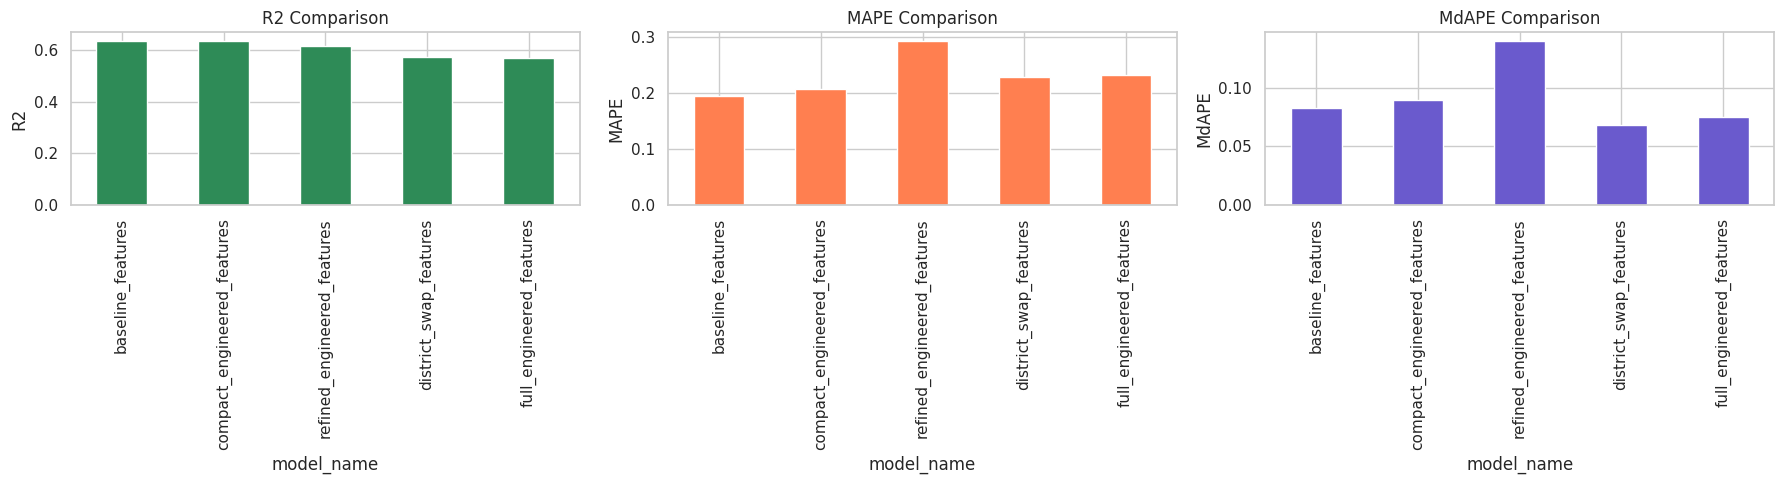

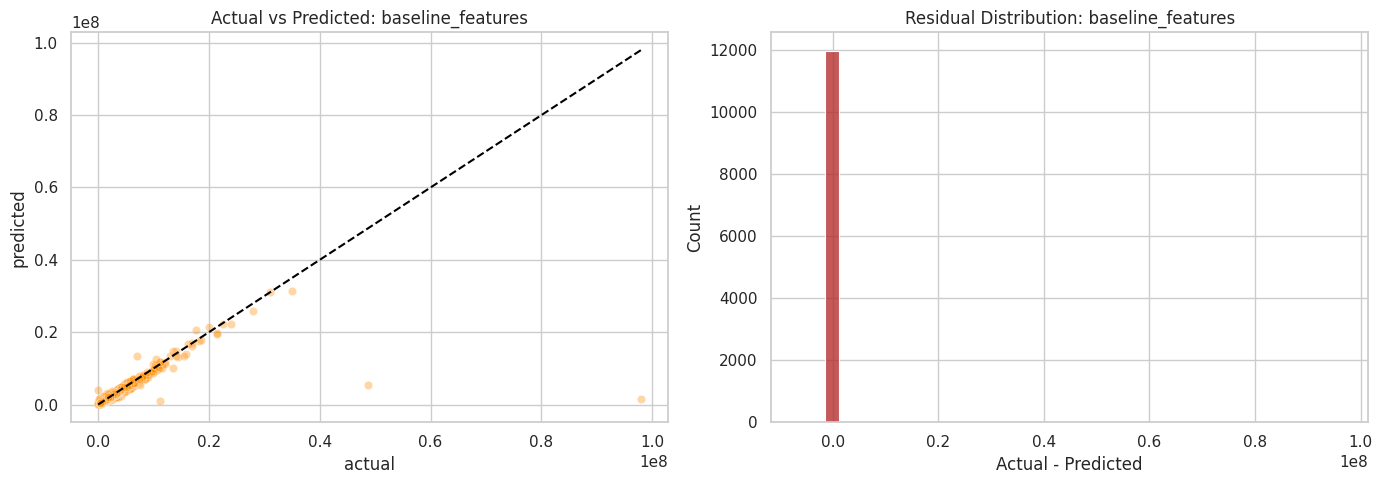

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_df.plot(
    x="model_name", y="R2", kind="bar", legend=False, color="seagreen", ax=axes[0]
)
axes[0].set_title("R2 Comparison")
axes[0].set_ylabel("R2")

results_df.plot(
    x="model_name", y="MAPE", kind="bar", legend=False, color="coral", ax=axes[1]
)
axes[1].set_title("MAPE Comparison")
axes[1].set_ylabel("MAPE")

results_df.plot(
    x="model_name", y="MdAPE", kind="bar", legend=False, color="slateblue", ax=axes[2]
)
axes[2].set_title("MdAPE Comparison")
axes[2].set_ylabel("MdAPE")

plt.tight_layout()
plt.show()

best_model_name = results_df.loc[0, "model_name"]
best_predictions = predictions_df[
    predictions_df["model_name"] == best_model_name
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=best_predictions,
    x="actual",
    y="predicted",
    alpha=0.35,
    ax=axes[0],
    color="darkorange",
)
axes[0].plot(
    [best_predictions["actual"].min(), best_predictions["actual"].max()],
    [best_predictions["actual"].min(), best_predictions["actual"].max()],
    linestyle="--",
    color="black",
)
axes[0].set_title(f"Actual vs Predicted: {best_model_name}")

sns.histplot(best_predictions["residual"], bins=40, ax=axes[1], color="firebrick")
axes[1].set_title(f"Residual Distribution: {best_model_name}")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()

In [27]:
engineered_output_path = output_dir / "week6_feature_engineered_dataset.csv"
results_output_path = output_dir / "week6_feature_engineering_results.csv"
predictions_output_path = output_dir / "week6_best_model_predictions.csv"

engineered_df.to_csv(engineered_output_path, index=False)
results_df.to_csv(results_output_path, index=False)
best_predictions.to_csv(predictions_output_path, index=False)

print(f"Saved engineered dataset to: {engineered_output_path}")
print(f"Saved comparison results to: {results_output_path}")
print(f"Saved best-model predictions to: {predictions_output_path}")

results_df

Saved engineered dataset to: /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/week6_feature_engineered_dataset.csv
Saved comparison results to: /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/week6_feature_engineering_results.csv
Saved best-model predictions to: /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/week6_best_model_predictions.csv


,model_name,train_rows,test_rows,MAE,RMSE,R2,MAPE,MdAPE
0,baseline_features,59505,12021,175982.73,1009587.58,0.6372,0.1952,0.0823
1,compact_engineered_features,59505,12021,185062.61,1011356.22,0.6359,0.2074,0.0892
2,refined_engineered_features,59505,12021,241948.09,1039384.47,0.6154,0.2933,0.1402
3,district_swap_features,59505,12021,187473.71,1093699.74,0.5742,0.2290,0.0685
4,full_engineered_features,59505,12021,198825.53,1100660.12,0.5688,0.2315,0.0746


## Final Week 6 Conclusion

Week 6 is complete once the new engineered features are created, the unified school district has been joined, and several feature-engineering strategies have been compared on the same holdout month.

In the final comparison, `baseline_features` remained the strongest overall specification. The compact engineered version came close but did not improve on the retained baseline, while the district-based, refined, and fully expanded engineered versions reduced overall performance on the unchanged holdout month.

The school-district join was still useful as a documented feature-engineering experiment because it showed that unified district information can be added successfully to the dataset. However, in the current linear-regression setup, none of the engineered versions outperformed the retained baseline on overall `R2` and `MAPE`.

Taken together, the Week 6 results suggest that the original baseline already captures the main signal available from this feature set, and that future gains are more likely to come from stronger model families, richer location detail, or more property-quality variables rather than small linear-regression feature additions alone.